Performs logistic regression on `mcts2.txt`, a CSV generated by `bin/mcts2.rs` with the following:

- `black_rollouts` number of MCTS rollouts performed by the black player (goes first)
- `white_rollouts` number of MCTS rollouts performed by the white player (goes second)
- `result` 1 or 0 depending on whether black won

400 matchups were generated randomly with $121^X$ rollouts per player, where $X$ is selected uniformly from $2.0$ to $3.5$. $X$ is expected to be roughly proportional to the depth of the tree explored by that player.

In [1]:
import csv
import math
import numpy as np

xs = []
ys = []
with open('mcts2.txt') as f:
    reader = csv.DictReader(f)
    for row in reader:
        black_rollouts = float(row['black_rollouts'])
        white_rollouts = float(row['white_rollouts'])
        xs.append(math.log10(black_rollouts / white_rollouts))
        ys.append(float(row['result']))

xs = np.array(xs)
ys = np.array(ys)

np.stack([xs, ys]).shape

(2, 400)

In [2]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(xs.reshape((-1, 1)), ys)
model.n_iter_

array([6], dtype=int32)

b0 = 0.3400141766165969
b1 = 1.8306906890363333


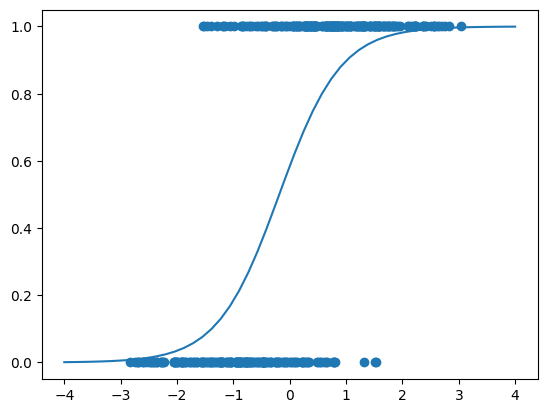

In [3]:
import matplotlib.pyplot as plt

b0 = model.intercept_[0]
b1 = model.coef_[0,0]
print('b0 =', b0)
print('b1 =', b1)

def predict(x):
    return 1. / (1. + np.exp(-(b0 + b1 * x)))

x = np.linspace(-4, 4)
y = predict(x)
plt.plot(x, y)
plt.scatter(xs, ys)
plt.show()

In [4]:
x = np.arange(-2, 2, 0.5)
y = predict(x)
print(np.stack([x, y]).T)

[[-2.          0.0348454 ]
 [-1.5         0.08271465]
 [-1.          0.18382021]
 [-0.5         0.3600076 ]
 [ 0.          0.58419397]
 [ 0.5         0.77822624]
 [ 1.          0.89758778]
 [ 1.5         0.95631365]]


In [5]:
def to_mcts(x):
    return np.pow(10.0, x)
def to_elo(x):
    return 400.0 * (b0 + b1 * x)

x = np.arange(-1, 2.01, 0.25)
y = to_elo(x)+1500
x = to_mcts(x)*100000
print(f'{'ROLLOUTS':>10} {'ELO':>10}')
for x, y in zip(x, y):
    print(f'{x:10.0f} {y:10.0f}')

  ROLLOUTS        ELO
     10000        904
     17783       1087
     31623       1270
     56234       1453
    100000       1636
    177828       1819
    316228       2002
    562341       2185
   1000000       2368
   1778279       2551
   3162278       2734
   5623413       2917
  10000000       3101


The above table shows the effective Elo rating of the black player when using the given number of rollouts and playing against a white player with elo 1500 and using 100,000 rollouts.